# Base Line Experiment

In [ ]:
import pandas as pd
from transformers import pipeline

# List Model

MODEL_REGISTRY = {
    "cahya": {
        "type": "hf",
        "model": "cahya/bert-base-indonesian-NER",
        "tokenizer": "cahya/bert-base-indonesian-NER"
    },


    "xlmr": {
        "type": "hf",
        "model": "Davlan/xlm-roberta-base-ner-hrl",
        "tokenizer": "Davlan/xlm-roberta-base-ner-hrl"
    },
    "flair": {
        "type": "flair",
        "model": "flair/ner-indonesian-large"
    }
}

# Load Model
loaded_models = {}

for name, cfg in MODEL_REGISTRY.items():
    if cfg["type"] == "hf":
        print(f"🔄 Load Hugging Face model: {name}")
        loaded_models[name] = pipeline(
            "ner",
            model=cfg["model"],
            tokenizer=cfg["tokenizer"],
            aggregation_strategy="simple"
        )

print("Semua model berhasil dimuat!")



In [ ]:
def extract_entities(text, model_pipeline):
    hasil = model_pipeline(str(text))
    entities = {"PER": [], "ORG": [], "LOC": []}
    for ent in hasil:
        label = ent.get("entity_group") or ent.get("label")
        word = ent.get("word") or ent.get("text")
        label = label.split("-")[-1]
        if label in entities:
            entities[label].append(word)
    return entities


df = pd.read_csv("/content/2025_09_gt.csv")


for model_name, model_pipeline in loaded_models.items():
    print(f"Running NER dengan model: {model_name}")
    df[f"{model_name}_entities"] = df["summary"].apply(lambda x: extract_entities(x, model_pipeline))

    df[f"{model_name}_PER"] = df[f"{model_name}_entities"].apply(lambda x: x["PER"])
    df[f"{model_name}_ORG"] = df[f"{model_name}_entities"].apply(lambda x: x["ORG"])
    df[f"{model_name}_LOC"] = df[f"{model_name}_entities"].apply(lambda x: x["LOC"])

print("Selesai! Hasil disimpan")


In [ ]:
# Format Output

columns_to_drop = [f"{name}_entities" for name in loaded_models.keys()]
df = df.drop(columns=columns_to_drop)


model_prefixes = ['gt', 'old'] + list(loaded_models.keys())
entity_types = ['PER', 'LOC', 'ORG']

new_column_order = ['hashtitle', 'summary']
for entity in entity_types:
    for prefix in model_prefixes:
        column_name = f"{prefix}_{entity}"
        if column_name in df.columns:
            new_column_order.append(column_name)

remaining_columns = [col for col in df.columns if col not in new_column_order]
final_order = new_column_order + remaining_columns

df = df[final_order]

print("Urutan kolom berhasil diatur!")
print("Urutan kolom baru:", df.columns.tolist())

In [ ]:
df

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Baseline Evaluation

In [ ]:
import pandas as pd
import ast
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def normalize_list(x):
    """Normalisasi input menjadi list of lowercase string."""
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
    if not isinstance(x, list):
        return []
    return [str(i).lower().strip() for i in x if i]

def evaluate_ner(df, model_prefix):
    """
    Fungsi untuk mengevaluasi hasil NER dengan metrik precision, recall, dan f1-score.
    """
    results = {}

    column_mapping = [
        ("PER", "gt_PER", f"{model_prefix}_PER"),
        ("ORG", "gt_ORG", f"{model_prefix}_ORG"),
        ("LOC", "gt_LOC", f"{model_prefix}_LOC"),
    ]

    for label, col_gt, col_pred in column_mapping:
        y_true_all, y_pred_all = [], []

        for _, row in df.iterrows():
            y_true = set(normalize_list(row[col_gt]))
            y_pred = set(normalize_list(row[col_pred]))

            all_entities = y_true.union(y_pred)
            if not all_entities:
                continue

            for ent in all_entities:
                y_true_all.append(1 if ent in y_true else 0)
                y_pred_all.append(1 if ent in y_pred else 0)

        p, r, f, _ = precision_recall_fscore_support(
            y_true_all, y_pred_all, average="binary", zero_division=0
        )
        results[label] = {"precision": p, "recall": r, "f1": f}

    labels_for_avg = ["PER", "ORG", "LOC"]
    p_macro = np.mean([results[l]["precision"] for l in labels_for_avg])
    r_macro = np.mean([results[l]["recall"] for l in labels_for_avg])
    f_macro = np.mean([results[l]["f1"] for l in labels_for_avg])
    results["Macro Avg"] = {"precision": p_macro, "recall": r_macro, "f1": f_macro}

    return pd.DataFrame(results).T

# Evaluasi untuk model lama (menggunakan kolom 'old_PER', 'old_ORG', 'old_LOC')
old_results = evaluate_ner(df, "old")

# Evaluasi untuk model 'cahya'
cahya_results = evaluate_ner(df, "cahya")

# Evaluasi untuk model 'xlmr'
xlmr_results = evaluate_ner(df, "xlmr")

print("\nEvaluasi Old Model:\n", old_results, "\n")
print("Evaluasi Model Cahya:\n", cahya_results, "\n")
print("Evaluasi Model XLM-R:\n", xlmr_results)


Evaluasi Old Model:
            precision    recall        f1
PER         0.336842  0.581818  0.426667
ORG         0.196078  0.287356  0.233100
LOC         0.452514  0.413265  0.432000
Macro Avg   0.328478  0.427480  0.363922 

Evaluasi Model Cahya:
            precision    recall        f1
PER         0.438596  0.681818  0.533808
ORG         0.116541  0.178161  0.140909
LOC         0.111111  0.051020  0.069930
Macro Avg   0.222083  0.303667  0.248216 

Evaluasi Model XLM-R:
            precision    recall        f1
PER         0.478788  0.718182  0.574545
ORG         0.185484  0.396552  0.252747
LOC         0.348958  0.683673  0.462069
Macro Avg   0.337743  0.599469  0.429787


In [ ]:
all_results = {
    "old": old_results,
    "cahya": cahya_results,
    "xlmr": xlmr_results
}

f1_summary = pd.DataFrame({
    model_name: results['f1']
    for model_name, results in all_results.items()
})

f1_summary = f1_summary.reindex(['Macro Avg', 'PER', 'LOC', 'ORG'])
print(f1_summary)


 Tabel Ringkasan Perbandingan F1-Score
                old     cahya      xlmr
Macro Avg  0.363922  0.248216  0.429787
PER        0.426667  0.533808  0.574545
LOC        0.432000  0.069930  0.462069
ORG        0.233100  0.140909  0.252747


/tmp/ipython-input-2868914761.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=macro_avg_scores.index, y=macro_avg_scores.values, palette="viridis")


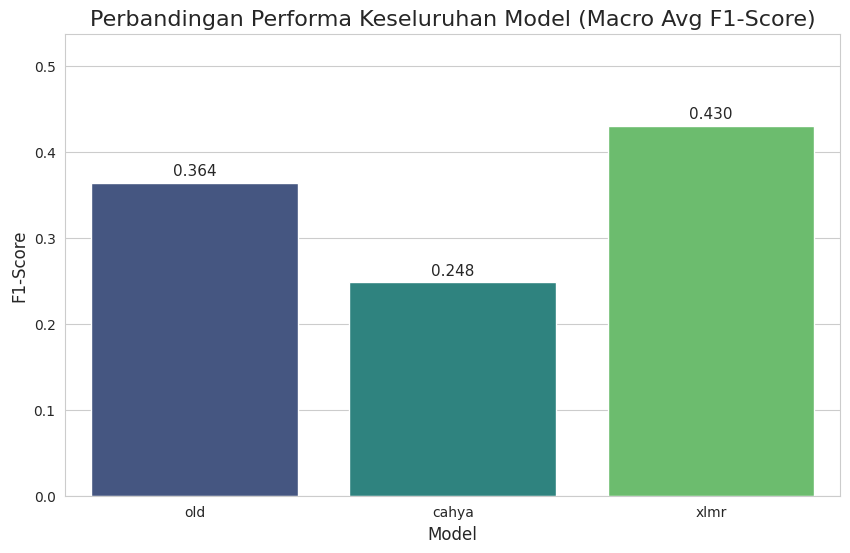

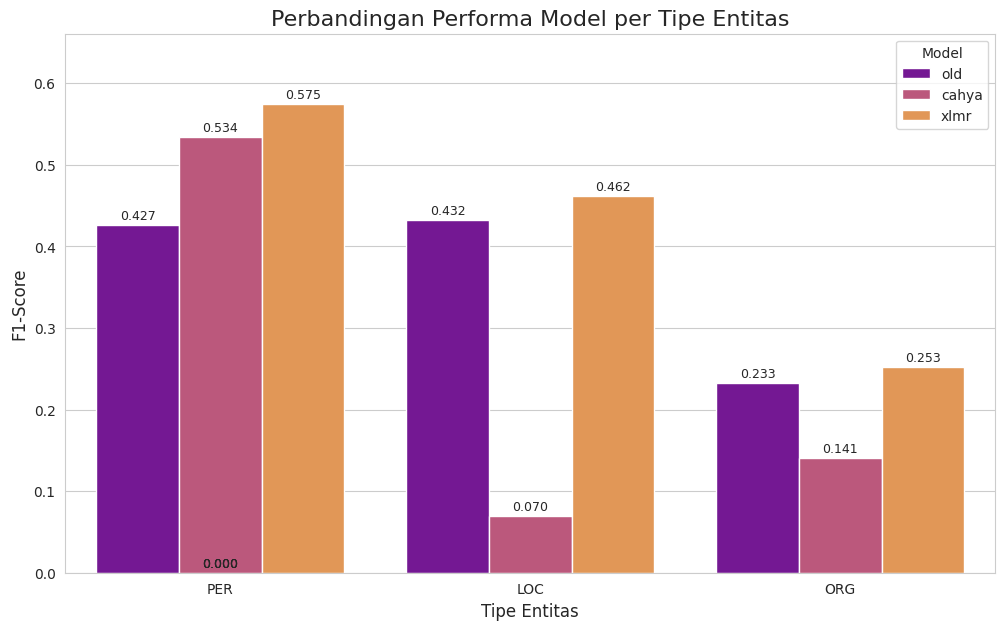

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
macro_avg_scores = f1_summary.loc['Macro Avg']

ax = sns.barplot(x=macro_avg_scores.index, y=macro_avg_scores.values, palette="viridis")

for patch in ax.patches:
    score = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        score + 0.005,
        f'{score:.3f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Perbandingan Performa Keseluruhan Model (Macro Avg F1-Score)', fontsize=16)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, max(macro_avg_scores.values) * 1.25)
plt.show()



f1_summary_melted = f1_summary.drop('Macro Avg').reset_index().rename(columns={'index': 'Entitas'})
f1_summary_melted = f1_summary_melted.melt(id_vars='Entitas', var_name='Model', value_name='F1-Score')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=f1_summary_melted, x='Entitas', y='F1-Score', hue='Model', palette="plasma")

for patch in ax.patches:
    score = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        score + 0.003,
        f'{score:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Perbandingan Performa Model per Tipe Entitas', fontsize=16)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Tipe Entitas', fontsize=12)
plt.legend(title='Model')

plt.ylim(0, f1_summary_melted['F1-Score'].max() * 1.15)

plt.show()

# Fine Tune XLMR Iteratif Progressive

In [5]:
# Dependencies

!pip install transformers datasets seqeval evaluate accelerate -q

import json
import numpy as np
from tqdm import tqdm
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
import evaluate
from google.colab import drive
from transformers import pipeline
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#GPU Check

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Current CUDA device:", torch.cuda.current_device())
print("CUDA device name:", torch.cuda.get_device_name(0))


TensorFlow version: 2.19.0
Num GPUs Available:  1
PyTorch version: 2.9.0+cu126
CUDA available: True
Current CUDA device: 0
CUDA device name: Tesla T4


In [6]:
# SETUP KONFIGURASI

JSON_PATH = "/content/1000 berita 2025_json.json"
BASE_MODEL = "/content/drive/MyDrive/Kuliah/Magang/SDD/Model/NER/xlmr_finetuned_ner_500"
MODEL_SAVE_NAME = "xlmr_finetuned_ner_1000"

In [7]:
# LOAD DATA JSON (Label Studio Format)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total data ditemukan: {len(data)}")

def create_bio_format_labelstudio(data):
    dataset = []
    for item in tqdm(data):
        text = item.get("data", {}).get("summary", "")
        if not text:
            continue

        entities = []
        annotations = item.get("annotations", [])
        if not annotations:
            continue

        results = annotations[0].get("result", [])
        for r in results:
            value = r.get("value", {})
            start = value.get("start")
            end = value.get("end")
            labels = value.get("labels", [])
            if start is None or end is None or not labels:
                continue
            entities.append({
                "start": start,
                "end": end,
                "label": labels[0]
            })

        dataset.append({"text": text, "entities": entities})
    return dataset

bio_data = create_bio_format_labelstudio(data)
print("Contoh data pertama:")
print(bio_data[0])

Total data ditemukan: 1000


100%|██████████| 1000/1000 [00:00<00:00, 67926.15it/s]

Contoh data pertama:
{'text': 'Mapos, Mamuju – Cabor Pickleball adalah salah satu olahraga dengan pertumbuhan paling cepat di dunia saat ini, termasuk di Indonesia, karena mudah dipelajari, menyenangkan, dan dapat dimainkan oleh berbagai usia.  Cabang olahraga pickleball resmi terdaftar keanggotaan di Komite Olahraga Nasional Indonesia (KONI) Kabupaten Mamuju.  Kepastian itu setelah pengurus International Pickleball Federation (IPF) Mamuju mempresentasikan mengenai cabang olahraga tersebut di depan pengurus KONI Mamuju.', 'entities': [{'start': 324, 'end': 330, 'label': 'LOC'}, {'start': 406, 'end': 412, 'label': 'LOC'}, {'start': 123, 'end': 132, 'label': 'LOC'}, {'start': 364, 'end': 412, 'label': 'ORG'}, {'start': 272, 'end': 313, 'label': 'ORG'}]}


In [8]:
# TOKENISASI DAN ALIGN LABELS

MODEL_NAME = BASE_MODEL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
label_to_id = {l: i for i, l in enumerate(label_list)}

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256,
        return_offsets_mapping=True
    )

    all_labels = []
    for i, text in enumerate(examples["text"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        entity_labels = ["O"] * len(word_ids)

        if examples["entities"][i]:
            for ent in examples["entities"][i]:
                start, end, label = ent["start"], ent["end"], ent["label"]
                start_token, end_token = None, None
                for j, offset in enumerate(tokenized_inputs["offset_mapping"][i]):
                    if offset[0] <= start < offset[1]:
                        start_token = j
                    if offset[0] < end <= offset[1]:
                        end_token = j
                if start_token is not None and end_token is not None:
                    entity_labels[start_token] = f"B-{label}"
                    for k in range(start_token + 1, end_token + 1):
                        entity_labels[k] = f"I-{label}"

        all_labels.append([label_to_id.get(l, 0) for l in entity_labels])

    tokenized_inputs["labels"] = all_labels
    tokenized_inputs.pop("offset_mapping")
    return tokenized_inputs

dataset = Dataset.from_list(bio_data)
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [9]:
# SPLIT TRAIN/TEST

split_dataset = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print("Train size:", len(train_dataset))
print("Eval size:", len(eval_dataset))

Train size: 800
Eval size: 200


In [10]:
# FINE-TUNING

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    ignore_mismatched_sizes=True
)

args = TrainingArguments(
    output_dir=f"./{MODEL_SAVE_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=20,
    push_to_hub=False,
)

data_collator = DataCollatorForTokenClassification(tokenizer)
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_labels = [[label_list[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


/tmp/ipython-input-3335340011.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: azrilfahmiardi (azrilfahmiardi-universitas-gadjah-mada) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.081300,0.083687,0.617995,0.672680,0.644179,0.972090
2,0.068900,0.085693,0.574380,0.716495,0.637615,0.971230
3,0.047000,0.094406,0.585724,0.719072,0.645584,0.970898
4,0.035800,0.093389,0.602760,0.713058,0.653286,0.971270


TrainOutput(global_step=800, training_loss=0.060927903130650524, metrics={'train_runtime': 756.2581, 'train_samples_per_second': 4.231, 'train_steps_per_second': 1.058, 'total_flos': 418093709721600.0, 'train_loss': 0.060927903130650524, 'epoch': 4.0})

In [ ]:
# SIMPAN MODEL & EVALUASI

results = trainer.evaluate()
print("Hasil Evaluasi Akhir:")
print(results)

SAVE_PATH = f"/content/drive/MyDrive/Kuliah/Magang/SDD/Model/NER/{MODEL_SAVE_NAME}"
trainer.save_model(SAVE_PATH)
print(f"Model tersimpan di: {SAVE_PATH}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📊 Hasil Evaluasi Akhir:
{'eval_loss': 0.07442276924848557, 'eval_precision': 0.667601683029453, 'eval_recall': 0.779050736497545, 'eval_f1': 0.7190332326283988, 'eval_accuracy': 0.9791015625, 'eval_runtime': 102.1856, 'eval_samples_per_second': 0.979, 'eval_steps_per_second': 0.245, 'epoch': 4.0}
✅ Model tersimpan di: /content/drive/MyDrive/Kuliah/Magang/SDD/Model/NER/xlmr_finetuned_ner_500


In [ ]:
# Setup Finetuned Model

model_path = SAVE_PATH
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForTokenClassification.from_pretrained(model_path, local_files_only=True)

# Label list
label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]

# Pipeline NER
ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

# Result Converter
def predict_entities(text):
    preds = ner_pipeline(text)
    merged = []
    prev_label = None
    current_entity = ""
    current_score = []

    for pred in preds:
        label_idx = int(pred["entity_group"].split("_")[-1])
        full_label = label_list[label_idx] if label_idx < len(label_list) else "O"
        if full_label == "O":
            if prev_label:
                merged.append({
                    "entity": prev_label,
                    "word": current_entity.strip(),
                    "score": round(sum(current_score) / len(current_score), 3)
                })
                prev_label, current_entity, current_score = None, "", []
            continue

        label = full_label.split("-")[-1]

        if label == prev_label:
            current_entity += " " + pred["word"]
            current_score.append(float(pred["score"]))
        else:
            if prev_label:
                merged.append({
                    "entity": prev_label,
                    "word": current_entity.strip(),
                    "score": round(sum(current_score) / len(current_score), 3)
                })
            prev_label = label
            current_entity = pred["word"]
            current_score = [float(pred["score"])]

    if prev_label:
        merged.append({
            "entity": prev_label,
            "word": current_entity.strip(),
            "score": round(sum(current_score) / len(current_score), 3)
        })

    return merged

Device set to use cpu


In [ ]:
# Prediksi Sebuah News

text = "HOLOPIS.COM, JAKARTA – Menteri Pemuda dan Olahraga Republik Indonesia (Menpora RI) Dito Ariotedjo mendampingi Wakil Presiden Gibran Rakabuming Raka menutup Festival Olahraga Masyarakat Nasional (FORNAS) VIII Nusa Tenggara Barat (NTB) 2025. Penutupan Fornas ditandai dengan penabuhan gendang baleq oleh Wapres Gibran, Menpora Dito, dan Gubernur NTB Lalu Muhammad Iqbal di atas panggung lapangan eks Bandara Selaparang, Mataram, Jumat (1/8). Wapres Gibran terkesan dengan penyelenggaraan Fornas tahun ini."
entities = predict_entities(text)

for e in entities:
    print(e)

{'entity': 'ORG', 'word': 'Menteri Pemuda dan Olahraga Republik Indonesia (Menpora RI)', 'score': 0.89}
{'entity': 'PER', 'word': 'Dit o Ariotedjo', 'score': 0.988}
{'entity': 'PER', 'word': 'Gi bran Rakabuming Raka', 'score': 0.988}
{'entity': 'LOC', 'word': 'Nu sa Tenggara Barat', 'score': 0.831}
{'entity': 'PER', 'word': 'Gi bran', 'score': 0.728}
{'entity': 'PER', 'word': 'Dit o', 'score': 0.681}
{'entity': 'LOC', 'word': 'NTB', 'score': 0.94}
{'entity': 'PER', 'word': 'Lalu Muhammad Iqbal', 'score': 0.986}
{'entity': 'LOC', 'word': 'pa nggung lapangan eks Bandar a Selaparang', 'score': 0.657}
{'entity': 'LOC', 'word': 'Mata ram', 'score': 0.973}
{'entity': 'PER', 'word': 'Gi bran', 'score': 0.813}
